In [1]:
import os
from torchvision import datasets , transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models
from matplotlib import pyplot as plt
import optuna

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Load Data

In [4]:
image_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness = 0.2 , contrast = 0.2),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean =[0.485 , 0.456 , 0.406] , std =[0.229 , 0.224 , 0.225])  # from imagenet
])

In [5]:
dataset_path = "./dataset"

dataset = datasets.ImageFolder(dataset_path , transform = image_transforms)
len(dataset)

2300

In [6]:
dataset.classes

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [7]:
num_classes = len(dataset.classes)
num_classes

6

In [8]:
train_size = int(0.75 * len(dataset))
val_size = len(dataset) - train_size
train_size , val_size

(1725, 575)

In [9]:
from torch.utils.data import random_split

train_dataset , val_dataset = random_split(dataset , [train_size , val_size])

In [10]:
train_loader = DataLoader(train_dataset , batch_size=32 , shuffle = True)
val_loader = DataLoader(val_dataset , batch_size=32 , shuffle=True)

In [11]:
for images , labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [12]:
labels[0]

tensor(2)

In [13]:
images[0].shape

torch.Size([3, 224, 224])

In [14]:
images[0].permute(1,2,0).shape

torch.Size([224, 224, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


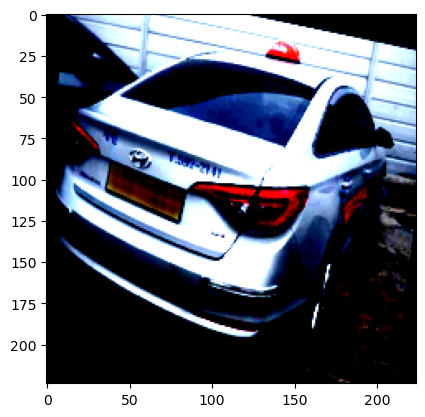

In [15]:
plt.imshow(images[20].permute(1,2,0))
plt.show()

### Model 1 : CNN

In [16]:
class CarClassifierCNN(nn.Module):
    def __init__(self , num_classes):
        super().__init__()
        self.network = nn.Sequential(   
            nn.Conv2d(in_channels=3, out_channels = 16 ,kernel_size = 3 ,stride= 1 ,padding =1), # in (3,224,224) out - (16,224,224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # out (16 , 112,112),

            nn.Conv2d(in_channels=16, out_channels = 32 ,kernel_size = 3 ,stride= 1 ,padding =1), # in (16,112,112) out - (32 ,112,112)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # out (32,56,56)

            nn.Conv2d(in_channels=32, out_channels = 64 ,kernel_size = 3 ,stride= 1 ,padding =1) ,# in (32,56,56) out - (64,56,56)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # out (64 ,28,28),
            
            nn.Flatten(),
            nn.Linear(64*28*28 , 512),
            nn.ReLU(),
            nn.Linear(512 , num_classes),
        )

    def forward(self,x):
        x = self.network(x)
        return x
        

In [17]:
model = CarClassifierCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters() , lr = 0.001)

In [18]:
len(train_loader) #number of batches , len(train_loader.dataset) # number of images

54

In [19]:
def train_model(model , criterion , optimizer , epochs = 5):
    start = time.time()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num , (images , labels) in enumerate(train_loader):
            images , labels = images.to(device) , labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            #forward pass
            outputs = model(images)
            loss = criterion(outputs , labels)
            
            #backword pass and optimizer
            loss.backward()
            optimizer.step()

            if (batch_num+1) % 10 == 0:
                print(f"Batch : {batch_num+1} , Epoch: {epoch+1} , Loss: {loss.item(): 0.2f}")

            running_loss += loss.item() * images.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}] , Avg loss: {epoch_loss: .4f}")

        # validation
        model.eval()
        correct=0
        total=0
        all_labels = []
        all_predictions =[]

        with torch.no_grad():
            for images , labels in val_loader:
                images , labels = images.to(device) , labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data,1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())
            print(f"*** Validation Accuracy : {100 * correct / total:.2f}% ***")
    end = time.time()
    print(f"Execution time : {end-start} seconds")
    return all_labels , all_predictions      

In [20]:
train_model(model , criterion , optimizer , epochs =10)

Batch : 10 , Epoch: 1 , Loss:  1.79
Batch : 20 , Epoch: 1 , Loss:  1.80
Batch : 30 , Epoch: 1 , Loss:  1.73
Batch : 40 , Epoch: 1 , Loss:  1.68
Batch : 50 , Epoch: 1 , Loss:  1.47
Epoch [1/10] , Avg loss:  1.9945
*** Validation Accuracy : 42.96% ***
Batch : 10 , Epoch: 2 , Loss:  1.38
Batch : 20 , Epoch: 2 , Loss:  1.32
Batch : 30 , Epoch: 2 , Loss:  1.60
Batch : 40 , Epoch: 2 , Loss:  1.42
Batch : 50 , Epoch: 2 , Loss:  1.22
Epoch [2/10] , Avg loss:  1.3323
*** Validation Accuracy : 47.13% ***
Batch : 10 , Epoch: 3 , Loss:  1.10
Batch : 20 , Epoch: 3 , Loss:  1.74
Batch : 30 , Epoch: 3 , Loss:  1.25
Batch : 40 , Epoch: 3 , Loss:  1.26
Batch : 50 , Epoch: 3 , Loss:  1.53
Epoch [3/10] , Avg loss:  1.2216
*** Validation Accuracy : 47.83% ***
Batch : 10 , Epoch: 4 , Loss:  1.32
Batch : 20 , Epoch: 4 , Loss:  1.41
Batch : 30 , Epoch: 4 , Loss:  1.13
Batch : 40 , Epoch: 4 , Loss:  1.28
Batch : 50 , Epoch: 4 , Loss:  1.21
Epoch [4/10] , Avg loss:  1.1638
*** Validation Accuracy : 49.57% ***


([1,
  0,
  4,
  0,
  1,
  2,
  5,
  0,
  4,
  4,
  1,
  1,
  1,
  3,
  2,
  0,
  3,
  0,
  5,
  3,
  4,
  5,
  2,
  0,
  4,
  0,
  2,
  2,
  5,
  0,
  0,
  2,
  0,
  2,
  0,
  1,
  1,
  1,
  1,
  0,
  2,
  1,
  2,
  1,
  0,
  4,
  4,
  3,
  1,
  4,
  3,
  5,
  1,
  2,
  0,
  4,
  1,
  0,
  2,
  1,
  0,
  5,
  3,
  0,
  3,
  0,
  1,
  0,
  1,
  4,
  4,
  0,
  0,
  0,
  5,
  3,
  0,
  2,
  5,
  4,
  1,
  4,
  4,
  4,
  1,
  0,
  0,
  0,
  4,
  2,
  1,
  0,
  1,
  4,
  5,
  1,
  3,
  2,
  5,
  1,
  0,
  4,
  1,
  5,
  4,
  3,
  2,
  4,
  4,
  3,
  1,
  5,
  4,
  1,
  3,
  5,
  5,
  2,
  0,
  4,
  0,
  1,
  0,
  0,
  4,
  0,
  0,
  5,
  3,
  1,
  1,
  2,
  0,
  0,
  2,
  3,
  3,
  5,
  3,
  0,
  4,
  3,
  1,
  3,
  1,
  4,
  1,
  1,
  0,
  3,
  2,
  0,
  0,
  1,
  2,
  4,
  1,
  2,
  0,
  4,
  5,
  2,
  3,
  0,
  2,
  0,
  1,
  1,
  1,
  0,
  2,
  4,
  2,
  5,
  2,
  3,
  4,
  5,
  3,
  0,
  4,
  3,
  2,
  2,
  0,
  4,
  0,
  1,
  2,
  2,
  4,
  1,
  3,
  3,
  5,
  2,
  0,
  5,
  0,
  2,


### Model 2 : CNN with Regularization

In [24]:
class CarClassifierCNNWithRegularization(nn.Module):
    def __init__(self , num_classes):
        super().__init__()
        self.network = nn.Sequential(   
            nn.Conv2d(in_channels=3, out_channels = 16 ,kernel_size = 3 ,stride= 1 ,padding =1), # in (3,224,224) out - (16,224,224)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # out (16 , 112,112),

            nn.Conv2d(in_channels=16, out_channels = 32 ,kernel_size = 3 ,stride= 1 ,padding =1), # in (16,112,112) out - (32 ,112,112)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # out (32,56,56)

            nn.Conv2d(in_channels=32, out_channels = 64 ,kernel_size = 3 ,stride= 1 ,padding =1) ,# in (32,56,56) out - (64,56,56)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # out (64 ,28,28),
            
            nn.Flatten(),
            nn.Linear(64*28*28 , 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512 , num_classes),
        )

    def forward(self,x):
        x = self.network(x)
        return x
        

In [25]:
model = CarClassifierCNNWithRegularization(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters() , lr = 0.001 , weight_decay =1e-4 )
 
train_model(model , criterion , optimizer , epochs =10)

Batch : 10 , Epoch: 1 , Loss:  16.46
Batch : 20 , Epoch: 1 , Loss:  7.57
Batch : 30 , Epoch: 1 , Loss:  2.26
Batch : 40 , Epoch: 1 , Loss:  2.00
Batch : 50 , Epoch: 1 , Loss:  1.89
Epoch [1/10] , Avg loss:  9.1544
*** Validation Accuracy : 45.04% ***
Batch : 10 , Epoch: 2 , Loss:  1.47
Batch : 20 , Epoch: 2 , Loss:  1.79
Batch : 30 , Epoch: 2 , Loss:  1.20
Batch : 40 , Epoch: 2 , Loss:  1.08
Batch : 50 , Epoch: 2 , Loss:  1.05
Epoch [2/10] , Avg loss:  1.3766
*** Validation Accuracy : 49.74% ***
Batch : 10 , Epoch: 3 , Loss:  1.48
Batch : 20 , Epoch: 3 , Loss:  1.18
Batch : 30 , Epoch: 3 , Loss:  1.03
Batch : 40 , Epoch: 3 , Loss:  1.13
Batch : 50 , Epoch: 3 , Loss:  1.10
Epoch [3/10] , Avg loss:  1.2600
*** Validation Accuracy : 49.22% ***
Batch : 10 , Epoch: 4 , Loss:  1.14
Batch : 20 , Epoch: 4 , Loss:  1.12
Batch : 30 , Epoch: 4 , Loss:  1.20
Batch : 40 , Epoch: 4 , Loss:  1.10
Batch : 50 , Epoch: 4 , Loss:  1.15
Epoch [4/10] , Avg loss:  1.2169
*** Validation Accuracy : 50.78% ***

([4,
  2,
  3,
  0,
  2,
  0,
  1,
  0,
  2,
  1,
  1,
  2,
  1,
  4,
  0,
  0,
  4,
  4,
  0,
  5,
  1,
  1,
  3,
  2,
  4,
  0,
  4,
  3,
  5,
  1,
  0,
  0,
  1,
  1,
  3,
  4,
  3,
  2,
  4,
  2,
  1,
  5,
  2,
  0,
  0,
  3,
  1,
  4,
  1,
  5,
  2,
  0,
  0,
  2,
  5,
  1,
  2,
  0,
  5,
  2,
  0,
  0,
  3,
  0,
  2,
  0,
  0,
  2,
  0,
  0,
  2,
  2,
  1,
  2,
  0,
  2,
  0,
  3,
  3,
  0,
  3,
  1,
  1,
  2,
  3,
  5,
  3,
  0,
  0,
  1,
  1,
  2,
  2,
  4,
  3,
  4,
  4,
  5,
  0,
  3,
  3,
  0,
  1,
  5,
  5,
  2,
  0,
  1,
  2,
  5,
  0,
  1,
  0,
  3,
  0,
  1,
  0,
  4,
  2,
  3,
  1,
  3,
  3,
  5,
  4,
  4,
  1,
  0,
  3,
  1,
  5,
  5,
  0,
  1,
  4,
  4,
  2,
  1,
  3,
  2,
  1,
  2,
  5,
  4,
  2,
  1,
  4,
  2,
  5,
  4,
  0,
  0,
  4,
  1,
  4,
  1,
  0,
  0,
  5,
  1,
  0,
  3,
  1,
  4,
  2,
  2,
  1,
  1,
  5,
  0,
  1,
  2,
  0,
  0,
  5,
  1,
  1,
  0,
  1,
  4,
  2,
  4,
  2,
  0,
  5,
  1,
  2,
  5,
  0,
  2,
  5,
  1,
  5,
  4,
  4,
  1,
  0,
  3,
  2,
  1,


### Model 3: Transfer learning with EfficientNet

In [26]:
model = models.efficientnet_b0(weights ='DEFAULT')
model.classifier[1].in_features

1280

In [29]:
class CarClassifierEfficientNet(nn.Module):
    def __init__(self , num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(weights='DEFAULT')

        for param in self.model.parameters():
            param.requires_grad = False

        in_features = self.model.classifier[1].in_features

        self.model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features , num_classes)
        )

    def forward(self , x):
        x = self.model(x)
        return x 

        

In [30]:
model = CarClassifierEfficientNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p:p.requires_grad , model.parameters()) , lr =0.001)
 
train_model(model , criterion , optimizer , epochs =10)

Batch : 10 , Epoch: 1 , Loss:  1.69
Batch : 20 , Epoch: 1 , Loss:  1.49
Batch : 30 , Epoch: 1 , Loss:  1.49
Batch : 40 , Epoch: 1 , Loss:  1.46
Batch : 50 , Epoch: 1 , Loss:  1.21
Epoch [1/10] , Avg loss:  1.4905
*** Validation Accuracy : 58.26% ***
Batch : 10 , Epoch: 2 , Loss:  1.14
Batch : 20 , Epoch: 2 , Loss:  1.24
Batch : 30 , Epoch: 2 , Loss:  1.29
Batch : 40 , Epoch: 2 , Loss:  1.20
Batch : 50 , Epoch: 2 , Loss:  1.02
Epoch [2/10] , Avg loss:  1.1462
*** Validation Accuracy : 63.48% ***
Batch : 10 , Epoch: 3 , Loss:  0.87
Batch : 20 , Epoch: 3 , Loss:  1.04
Batch : 30 , Epoch: 3 , Loss:  1.04
Batch : 40 , Epoch: 3 , Loss:  1.07
Batch : 50 , Epoch: 3 , Loss:  0.84
Epoch [3/10] , Avg loss:  1.0246
*** Validation Accuracy : 61.91% ***
Batch : 10 , Epoch: 4 , Loss:  1.02
Batch : 20 , Epoch: 4 , Loss:  1.14
Batch : 30 , Epoch: 4 , Loss:  0.84
Batch : 40 , Epoch: 4 , Loss:  1.00
Batch : 50 , Epoch: 4 , Loss:  0.71
Epoch [4/10] , Avg loss:  0.9659
*** Validation Accuracy : 65.57% ***


([1,
  0,
  5,
  5,
  0,
  0,
  1,
  1,
  2,
  1,
  1,
  1,
  2,
  4,
  2,
  1,
  0,
  2,
  1,
  3,
  0,
  2,
  4,
  0,
  0,
  5,
  4,
  2,
  0,
  4,
  3,
  4,
  2,
  1,
  4,
  3,
  0,
  1,
  0,
  0,
  3,
  3,
  0,
  2,
  4,
  2,
  5,
  2,
  0,
  4,
  4,
  0,
  1,
  2,
  0,
  0,
  0,
  5,
  2,
  3,
  4,
  4,
  1,
  3,
  3,
  1,
  5,
  2,
  0,
  2,
  4,
  0,
  4,
  0,
  2,
  1,
  2,
  2,
  0,
  3,
  3,
  4,
  1,
  2,
  2,
  3,
  0,
  4,
  2,
  0,
  2,
  1,
  2,
  1,
  0,
  2,
  0,
  2,
  2,
  5,
  4,
  3,
  3,
  0,
  0,
  2,
  2,
  3,
  4,
  2,
  0,
  2,
  3,
  0,
  2,
  0,
  0,
  1,
  1,
  0,
  4,
  4,
  2,
  2,
  3,
  4,
  5,
  0,
  5,
  5,
  4,
  2,
  0,
  2,
  0,
  5,
  4,
  2,
  0,
  1,
  4,
  0,
  1,
  2,
  0,
  3,
  1,
  3,
  4,
  1,
  2,
  2,
  0,
  0,
  1,
  0,
  1,
  2,
  1,
  1,
  2,
  3,
  1,
  5,
  0,
  3,
  2,
  2,
  2,
  0,
  3,
  0,
  4,
  0,
  3,
  2,
  0,
  0,
  1,
  0,
  0,
  4,
  2,
  5,
  2,
  5,
  2,
  4,
  2,
  2,
  2,
  4,
  3,
  2,
  4,
  2,
  0,
  5,
  1,
  4,


### Model 4: Trnasfer learning with ResNet

In [35]:
model = models.resnet50(weights="DEFAULT")
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [40]:
class ClassifierRestNet(nn.Module):
    def __init__(self , num_classes):
        super().__init__()
        self.model = models.resnet50(weights = "DEFAULT")
        # Freeze all layers except the final fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False
            
        # Unfreeze layer4 and fc layers
        for param in self.model.layer4.parameters():
            param.requires_grad = True

        #replace the final fully connected layer
        self.model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.model.fc.in_features , num_classes)
        )
    def forward(self,x):
        x = self.model(x)
        return x

In [41]:
model = ClassifierRestNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p:p.requires_grad , model.parameters()) , lr =0.001)
 
labels , predictions = train_model(model , criterion , optimizer , epochs =10)

Batch : 10 , Epoch: 1 , Loss:  1.10
Batch : 20 , Epoch: 1 , Loss:  0.85
Batch : 30 , Epoch: 1 , Loss:  0.50
Batch : 40 , Epoch: 1 , Loss:  0.61
Batch : 50 , Epoch: 1 , Loss:  0.76
Epoch [1/10] , Avg loss:  0.8591
*** Validation Accuracy : 73.91% ***
Batch : 10 , Epoch: 2 , Loss:  0.64
Batch : 20 , Epoch: 2 , Loss:  0.46
Batch : 30 , Epoch: 2 , Loss:  0.42
Batch : 40 , Epoch: 2 , Loss:  0.55
Batch : 50 , Epoch: 2 , Loss:  0.30
Epoch [2/10] , Avg loss:  0.4893
*** Validation Accuracy : 75.30% ***
Batch : 10 , Epoch: 3 , Loss:  0.24
Batch : 20 , Epoch: 3 , Loss:  0.16
Batch : 30 , Epoch: 3 , Loss:  0.31
Batch : 40 , Epoch: 3 , Loss:  0.56
Batch : 50 , Epoch: 3 , Loss:  0.22
Epoch [3/10] , Avg loss:  0.3210
*** Validation Accuracy : 77.74% ***
Batch : 10 , Epoch: 4 , Loss:  0.30
Batch : 20 , Epoch: 4 , Loss:  0.30
Batch : 30 , Epoch: 4 , Loss:  0.19
Batch : 40 , Epoch: 4 , Loss:  0.15
Batch : 50 , Epoch: 4 , Loss:  0.13
Epoch [4/10] , Avg loss:  0.2506
*** Validation Accuracy : 78.43% ***


### Hyperparameter Tunning : Resnet

In [16]:
class CarClassifierRestNet(nn.Module):
    def __init__(self , num_classes , dropout_rate = 0.5):
        super().__init__()
        self.model = models.resnet50(weights = "DEFAULT")
        # Freeze all layers except the final fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False
            
        # Unfreeze layer4 and fc layers
        for param in self.model.layer4.parameters():
            param.requires_grad = True

        #replace the final fully connected layer
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features , num_classes)
        )
    def forward(self,x):
        x = self.model(x)
        return x

In [21]:
# define objective function for optuna
def objective(trial):
    # Suggest values for the hyperparameters
    lr = trial.suggest_float('lr' , 1e-5 , 1e-2 , log=True)
    dropout_rate = trial.suggest_float('dropout_rate' , 0.2 , 0.7)

    # load the model
    model = CarClassifierRestNet(num_classes = num_classes , dropout_rate=dropout_rate).to(device)

    #difine the loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad , model.parameters()), lr = lr)

    # Training loop
    epochs = 3
    start = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num ,(images , labels) in enumerate(train_loader):
            images, labels = images.to(device) , labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs , labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)

        # Validation loop
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images , labels in val_loader:
                images , labels = images.to(device) , labels.to(device)
                outputs = model(images)
                _,predicted = torch.max(outputs.data , 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct/total
        
        # report imidiate results to optuna
        trial.report(accuracy , epoch)

        # Handle pruning (if applicable)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    end = time.time()
    print(f"Execution time : {end-start} seconds")

    return accuracy
        
                

In [ ]:
#create the study and optimize
study = optuna.create_study(direction ='maximize') 
study.optimize(objective , n_trials=20)

In [21]:
model = CarClassifierRestNet(num_classes=num_classes , dropout_rate=0.2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p:p.requires_grad , model.parameters()) , lr =0.005)
 
labels , predictions = train_model(model , criterion , optimizer , epochs =10)

Batch : 10 , Epoch: 1 , Loss:  1.44
Batch : 20 , Epoch: 1 , Loss:  0.75
Batch : 30 , Epoch: 1 , Loss:  0.68
Batch : 40 , Epoch: 1 , Loss:  0.77
Batch : 50 , Epoch: 1 , Loss:  0.55
Epoch [1/10] , Avg loss:  0.9133
*** Validation Accuracy : 68.35% ***
Batch : 10 , Epoch: 2 , Loss:  0.49
Batch : 20 , Epoch: 2 , Loss:  0.78
Batch : 30 , Epoch: 2 , Loss:  0.97
Batch : 40 , Epoch: 2 , Loss:  0.42
Batch : 50 , Epoch: 2 , Loss:  0.76
Epoch [2/10] , Avg loss:  0.5350
*** Validation Accuracy : 75.83% ***
Batch : 10 , Epoch: 3 , Loss:  0.29
Batch : 20 , Epoch: 3 , Loss:  0.37
Batch : 30 , Epoch: 3 , Loss:  0.37
Batch : 40 , Epoch: 3 , Loss:  0.55
Batch : 50 , Epoch: 3 , Loss:  0.38
Epoch [3/10] , Avg loss:  0.4139
*** Validation Accuracy : 77.91% ***
Batch : 10 , Epoch: 4 , Loss:  0.25
Batch : 20 , Epoch: 4 , Loss:  0.34
Batch : 30 , Epoch: 4 , Loss:  0.37
Batch : 40 , Epoch: 4 , Loss:  0.48
Batch : 50 , Epoch: 4 , Loss:  0.32
Epoch [4/10] , Avg loss:  0.2802
*** Validation Accuracy : 79.48% ***


### Model Evaluation using Confusion Matrix and Classification Report

In [23]:
from sklearn.metrics import classification_report

report = classification_report(labels , predictions)
print(report)

              precision    recall  f1-score   support

           0       0.74      0.91      0.82       122
           1       0.82      0.77      0.79       104
           2       0.97      0.80      0.87       127
           3       0.59      0.89      0.71        71
           4       0.75      0.62      0.68        73
           5       0.91      0.67      0.77        78

    accuracy                           0.79       575
   macro avg       0.80      0.77      0.77       575
weighted avg       0.81      0.79      0.79       575



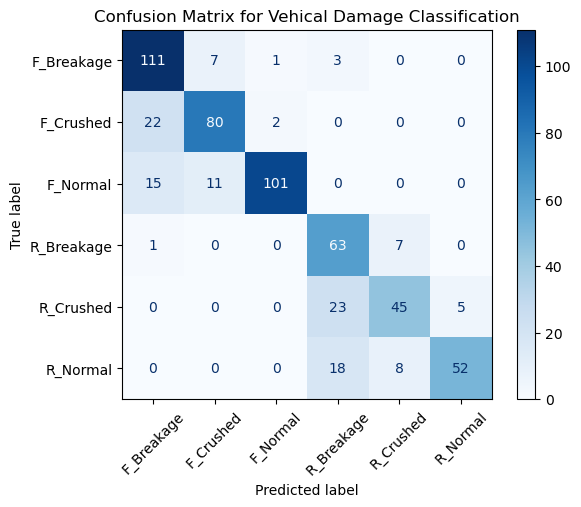

In [27]:
import numpy as np 
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay
from matplotlib import pyplot as plt

conf_matrix = confusion_matrix(labels , predictions , labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix = conf_matrix , display_labels = dataset.classes)
disp.plot(cmap =plt.cm.Blues , xticks_rotation = 45)
plt.title("Confusion Matrix for Vehical Damage Classification")
plt.show()

In [28]:
torch.save(model.state_dict() , 'saved_model.pth')